# Zhou 2026 vehicle data

This notebook lists the three released vehicles from the committed partition index, loads a few columns for one vehicle, and plots its daily median SOC. It makes no diagnosis.

## 1. Released units

This step lists what `systems('zhou2026')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('zhou2026')
display(released)

,unit,partitions,rows,first,last
0,LFP01,20,5118176,2019-05-05 12:09:30,2023-12-12 23:36:03
1,vehicle45,20,6103094,2019-05-09 16:13:24,2022-04-04 18:38:56
2,vehicle69,20,5015309,2019-05-09 16:20:03,2022-04-04 23:59:57


Each row is one vehicle identifier in the release with its partitions, rows and first and last timestamp. The paper's fleet is 133 vehicles.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('zhou2026', unit='vehicle45', columns=['SOC', 'TotalVoltage', 'TotalCurrent', 'ChargingStatus'])
print(frame.shape)
display(frame.head())

(6103094, 5)


,ChargingStatus,SOC,TotalCurrent,TotalVoltage,vin
Timestamp,,,,,
2019-05-09 16:13:24,3,61,65.8,356.9,vehicle45
2019-05-09 16:13:34,3,61,39.3,357.2,vehicle45
2019-05-09 16:13:44,3,61,-33.4,359.7,vehicle45
2019-05-09 16:13:54,3,61,3.2,360.5,vehicle45
2019-05-09 16:14:04,3,61,23.7,358.1,vehicle45


Four columns of vehicle45 over all 20 of its partitions. The per-cell strings are left out here because they need a lot of memory.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['SOC', 'TotalVoltage', 'TotalCurrent', 'ChargingStatus']].describe().T)

,count,mean,std,min,25%,50%,75%,max
SOC,6103094.0,66.057479,22.755662,0.0,49.0,69.0,85.0,100.0
TotalVoltage,6103094.0,365.940047,18.190934,0.0,349.8,364.6,381.4,403.8
TotalCurrent,6103094.0,-0.049068,20.896155,-225.1,-16.5,0.5,6.2,340.6
ChargingStatus,6103094.0,2.421978,0.909318,1.0,1.0,3.0,3.0,4.0


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

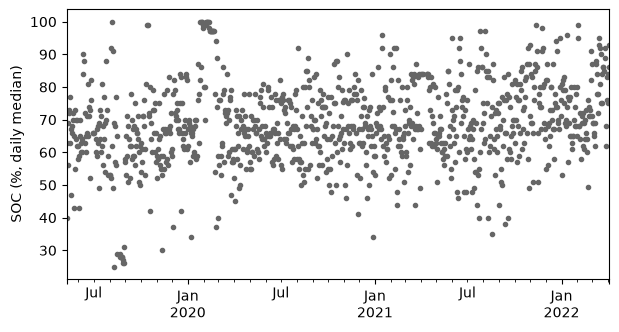

In [4]:
ax = frame['SOC'].resample('1D').median().plot(figsize=(7, 3.5), style='.', color='0.4')
ax.set_xlabel('')
ax.set_ylabel('SOC (%, daily median)')
plt.show()

Daily median SOC of vehicle45 over nearly three years of operation, with gaps where the vehicle did not report.